# VQC Controllability vs. Task Symmetry

### Improvements Included
1. **Quantified Expressibility** — Meyer-Wallach entanglement measure
2. **Barren Plateau Detection** — varianza del gradiente sobre inicializaciones
3. **Third dataset** — `antisymmetric_task` (control negativo)
4. **Generalization metrics** — generalization gap, convergence speed
5. **2D Loss landscape** — loss landscape slice alrededor del óptimo
6. **LaTeX table** — ready to insert in the paper

In [ ]:
# ── Instalación ──────────────────────────────────────────────────────────────
#!pip install qiskit --quiet

In [ ]:
import os
print(os.cpu_count())

20


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from itertools import combinations
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector, SparsePauliOp, partial_trace, entropy

np.random.seed(1234)
print('Imports OK')

Imports OK


---
## 1. Ansatz Circuit Definitions

In [ ]:
# ── Circuit A: fully expressive / maximal controllability ─────────────────────
def circuit_A_full(n=4, n_layers=2):
    qc = QuantumCircuit(n, name='A_full')

    theta_x  = ParameterVector('ax',  n_layers * n)
    theta_y  = ParameterVector('ay',  n_layers * n)
    theta_zz = ParameterVector('azz', n_layers * (n * (n - 1) // 2))

    kx, ky, kzz = 0, 0, 0

    for layer in range(n_layers):
        # Local single-qubit rotations
        for i in range(n):
            qc.rx(theta_x[kx], i)
            qc.ry(theta_y[ky], i)
            kx += 1
            ky += 1
        # All-to-all ZZ couplings
        for i in range(n):
            for j in range(i + 1, n):
                qc.rzz(theta_zz[kzz], i, j)
                kzz += 1

    params = list(theta_x) + list(theta_y) + list(theta_zz)
    return qc, params


# ── Circuit B: modular / structured controllability ───────────────────────────
def circuit_B_modular(n=4, n_layers=2):
    assert n == 4, "This modular prototype is fixed to 4 qubits."

    qc = QuantumCircuit(n, name='B_modular')

    theta_x  = ParameterVector('bx',  n_layers * n)
    theta_y  = ParameterVector('by',  n_layers * n)
    theta_zz = ParameterVector('bzz', n_layers * 2)  # two intra-block couplings per layer

    kx, ky, kzz = 0, 0, 0

    for layer in range(n_layers):
        # Local controls
        for i in range(n):
            qc.rx(theta_x[kx], i)
            qc.ry(theta_y[ky], i)
            kx += 1
            ky += 1
        # Block 1: qubits (0,1)
        qc.rzz(theta_zz[kzz], 0, 1)
        kzz += 1
        # Block 2: qubits (2,3)
        qc.rzz(theta_zz[kzz], 2, 3)
        kzz += 1

    params = list(theta_x) + list(theta_y) + list(theta_zz)
    return qc, params


# ── Circuit C: symmetry-aware / collective controllability ────────────────────
def circuit_C_symmetric(n=4, n_layers=4):
    qc = QuantumCircuit(n, name="C_symmetric_stable")

    theta_y  = ParameterVector("cy",  n_layers)
    theta_z  = ParameterVector("cz",  n_layers)
    theta_zz = ParameterVector("czz", n_layers)

    for layer in range(n_layers):

        # Collective Ry rotations
        for i in range(n):
            qc.ry(theta_y[layer], i)

        # Symmetric all-to-all ZZ interaction
        for i in range(n):
            for j in range(i + 1, n):
                qc.rzz(theta_zz[layer], i, j)

        # Collective Rz rotations
        for i in range(n):
            qc.rz(theta_z[layer], i)

    params = list(theta_y) + list(theta_zz) + list(theta_z)
    return qc, params


BUILDERS = {
    'A_full'     : circuit_A_full,      # n_layers=2 → 28 params
    'B_modular'  : circuit_B_modular,   # n_layers=2 → 20 params
    'C_symmetric': circuit_C_symmetric, # n_layers=5 → 20 params
}

# Draw the three circuits and confirm parameter count
for name, builder in BUILDERS.items():
    qc, params = builder()
    print(f'\n=== {name} ({len(params)} params) ===')
    print(qc.draw('text'))


=== A_full (28 params) ===
     ┌───────────┐┌───────────┐                                       »
q_0: ┤ Rx(ax[0]) ├┤ Ry(ay[0]) ├─■────────────■────────────■───────────»
     ├───────────┤├───────────┤ │ZZ(azz[0])  │            │           »
q_1: ┤ Rx(ax[1]) ├┤ Ry(ay[1]) ├─■────────────┼────────────┼───────────»
     ├───────────┤├───────────┤              │ZZ(azz[1])  │           »
q_2: ┤ Rx(ax[2]) ├┤ Ry(ay[2]) ├──────────────■────────────┼───────────»
     ├───────────┤├───────────┤                           │ZZ(azz[2]) »
q_3: ┤ Rx(ax[3]) ├┤ Ry(ay[3]) ├───────────────────────────■───────────»
     └───────────┘└───────────┘                                       »
«     ┌───────────┐┌───────────┐                                       »
«q_0: ┤ Rx(ax[4]) ├┤ Ry(ay[4]) ├───────────────────────────■───────────»
«     └───────────┘└───────────┘┌───────────┐┌───────────┐ │ZZ(azz[6]) »
«q_1: ─■────────────■───────────┤ Rx(ax[5]) ├┤ Ry(ay[5]) ├─■───────────»
«      │ZZ(azz[3])  │           

---
## 2. Expressibility Measure — Meyer-Wallach Entanglement

The *Meyer-Wallach measure* Q ∈ [0,1] quantifies how much entanglement
a circuit produces on average over the parameter space.  
Q = 0 → fully separable; Q = 1 → maximum entanglement.

In [ ]:
def meyer_wallach(builder, n_samples=200, n_qubits=4, seed=0):
    """
    Aproxima el Meyer-Wallach entanglement measure mediante muestreo.
    Q = (2/n) * sum_k E(rho_k) promediado sobre parámetros aleatorios.
    """
    rng = np.random.default_rng(seed)
    qc, params = builder()
    n_params = len(params)
    entanglements = []

    for _ in range(n_samples):
        theta = rng.uniform(0, 2 * np.pi, size=n_params)
        bind  = {p: v for p, v in zip(params, theta)}
        qc_b  = qc.assign_parameters(bind)

        sv  = Statevector.from_instruction(qc_b)
        ent = 0.0
        for k in range(n_qubits):
            # traza parcial sobre todos los qubits excepto k
            keep   = list(range(n_qubits))
            keep.remove(k)
            rho_k  = partial_trace(sv, keep)       # densidad del qubit k
            # entropía lineal = 1 - Tr(rho^2)
            lin_ent = 1.0 - np.real(np.trace(rho_k.data @ rho_k.data))
            ent    += lin_ent
        entanglements.append((2.0 / n_qubits) * ent)

    return float(np.mean(entanglements)), float(np.std(entanglements))


print('Computing Meyer-Wallach measure (may take ~1 min)...')
mw_results = {}
for name, builder in BUILDERS.items():
    mean_q, std_q = meyer_wallach(builder, n_samples=150)
    mw_results[name] = (mean_q, std_q)
    print(f'  {name:15s}  Q = {mean_q:.4f} ± {std_q:.4f}')

Computing Meyer-Wallach measure (may take ~1 min)...
  A_full           Q = 0.7427 ± 0.1301
  B_modular        Q = 0.3643 ± 0.1895
  C_symmetric      Q = 0.6644 ± 0.2401


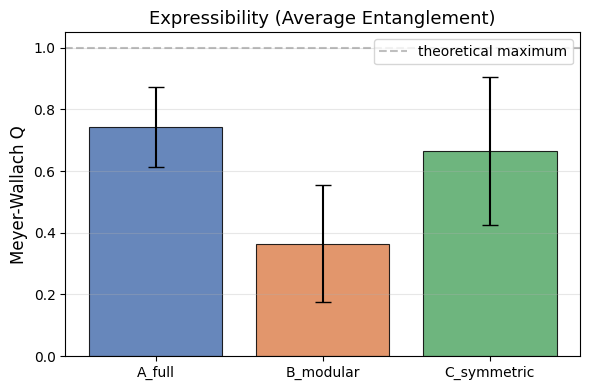

In [ ]:
# Expressibility visualization
fig, ax = plt.subplots(figsize=(6, 4))
names  = list(mw_results.keys())
means  = [mw_results[n][0] for n in names]
stds   = [mw_results[n][1] for n in names]
colors = ['#4C72B0', '#DD8452', '#55A868']

bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax.set_ylabel('Meyer-Wallach Q', fontsize=12)
ax.set_title('Expressibility (Average Entanglement)', fontsize=13)
ax.set_ylim(0, 1.05)
ax.axhline(1.0, ls='--', color='gray', alpha=0.5, label='theoretical maximum')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('expressibility.pdf', bbox_inches='tight')
plt.show()

---
## 3. Barren Plateau Detection

We sample the gradient variance over random initializations.  
A barren plateau manifests as **Var[∂L/∂θ] → 0** exponentially with the number of qubits/parameters.

In [ ]:
# ── Feature map & observable (usados también en el entrenamiento) ─────────────
def feature_map(x):
    n  = len(x)
    qc = QuantumCircuit(n, name='feature_map')
    for i in range(n):
        qc.ry(float(x[i]), i)
    return qc

def mean_Z_observable(n=4):
    paulis, coeffs = [], []
    for i in range(n):
        label = ['I'] * n
        label[n - 1 - i] = 'Z'
        paulis.append(''.join(label))
        coeffs.append(1.0 / n)
    return SparsePauliOp(paulis, coeffs)

OBS = mean_Z_observable(4)


def expectation_value(x, theta_values, ansatz_circuit, ansatz_params, observable=OBS):
    qc   = feature_map(x).compose(ansatz_circuit)
    bind = {p: v for p, v in zip(ansatz_params, theta_values)}
    sv   = Statevector.from_instruction(qc.assign_parameters(bind))
    return float(np.real(sv.expectation_value(observable)))

def predict_scores(X, theta_values, ansatz_circuit, ansatz_params, observable=OBS):
    return np.array([expectation_value(x, theta_values, ansatz_circuit, ansatz_params, observable) for x in X])

def predict_labels(X, theta_values, ansatz_circuit, ansatz_params, observable=OBS):
    return np.where(predict_scores(X, theta_values, ansatz_circuit, ansatz_params, observable) >= 0.0, 1, -1)

def mse_loss(X, y, theta_values, ansatz_circuit, ansatz_params, observable=OBS):
    preds = predict_scores(X, theta_values, ansatz_circuit, ansatz_params, observable)
    return float(np.mean((preds - y) ** 2))

def accuracy(X, y, theta_values, ansatz_circuit, ansatz_params, observable=OBS):
    return float(np.mean(predict_labels(X, theta_values, ansatz_circuit, ansatz_params, observable) == y))

def parameter_shift_gradient(X, y, theta_values, ansatz_circuit, ansatz_params, observable=OBS):
    grad  = np.zeros_like(theta_values, dtype=float)
    shift = np.pi / 2.0
    for k in range(len(theta_values)):
        tp = theta_values.copy(); tp[k] += shift
        tm = theta_values.copy(); tm[k] -= shift
        dp = predict_scores(X, tp, ansatz_circuit, ansatz_params, observable)
        dm = predict_scores(X, tm, ansatz_circuit, ansatz_params, observable)
        p  = predict_scores(X, theta_values, ansatz_circuit, ansatz_params, observable)
        grad[k] = np.mean(2.0 * (p - y) * 0.5 * (dp - dm))
    return grad

print('Circuit functions defined.')

Circuit functions defined.


In [ ]:
def barren_plateau_variance(builder, n_init=40, n_qubits=4, seed=42):
    """
    Estima la varianza de cada componente del gradiente
    sobre n_init inicializaciones aleatorias con un batch pequeño fijo.
    Devuelve la varianza media sobre todos los parámetros.
    """
    rng = np.random.default_rng(seed)
    # batch fijo de 8 puntos para estimar el gradiente
    X_bp = rng.uniform(0, np.pi, size=(8, n_qubits))
    y_bp = rng.choice([-1, 1], size=8)

    qc, params = builder()
    n_params = len(params)
    grads = []

    for _ in range(n_init):
        theta = rng.uniform(0, 2 * np.pi, size=n_params)
        g = parameter_shift_gradient(X_bp, y_bp, theta, qc, params)
        grads.append(g)

    grads = np.array(grads)           # shape: (n_init, n_params)
    var_per_param = np.var(grads, axis=0)
    return float(np.mean(var_per_param)), grads


print('Computing gradient variance (Barren Plateau)...')
bp_results = {}
bp_grads   = {}
for name, builder in BUILDERS.items():
    var, grads = barren_plateau_variance(builder, n_init=30)
    bp_results[name] = var
    bp_grads[name]   = grads
    print(f'  {name:15s}  Var[grad] = {var:.6f}')

Computing gradient variance (Barren Plateau)...
  A_full           Var[grad] = 0.006085
  B_modular        Var[grad] = 0.009607
  C_symmetric      Var[grad] = 0.061462


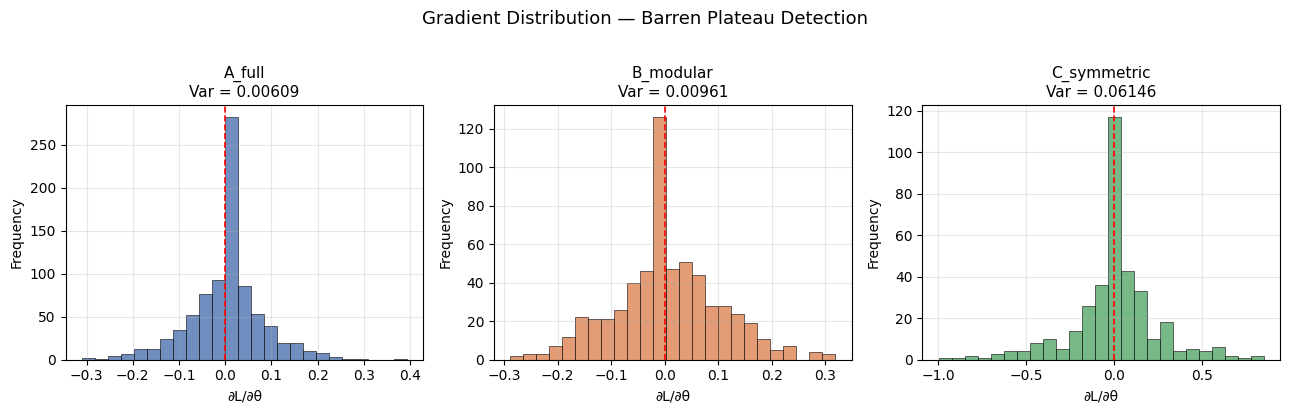

In [ ]:
# Barren Plateau visualization — gradient distribution per circuit
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, (name, grads), color in zip(axes, bp_grads.items(), colors):
    flat = grads.flatten()
    ax.hist(flat, bins=25, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='red', ls='--', lw=1.2)
    ax.set_title(f'{name}\nVar = {bp_results[name]:.5f}', fontsize=11)
    ax.set_xlabel('∂L/∂θ', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Gradient Distribution — Barren Plateau Detection', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('barren_plateau.pdf', bbox_inches='tight')
plt.show()

---
## 4. Datasets

In [ ]:
# ── Dataset 1: generic_moons ──────────────────────────────────────────────────
def dataset_generic_moons(n_samples=160, noise=0.12, test_size=0.25, seed=123):
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=seed)
    x1, x2 = X[:, 0], X[:, 1]
    X4 = np.column_stack([x1, x2, x1 * x2, x1**2 - x2**2])
    X4 = MinMaxScaler(feature_range=(0.0, np.pi)).fit_transform(X4)
    y_pm = 2 * y - 1
    return train_test_split(X4, y_pm, test_size=test_size, random_state=seed, stratify=y_pm)


# ── Dataset 2: symmetric_task ─────────────────────────────────────────────────
# Label = sign(sum of features) → invariant under permutations
def dataset_symmetric(n_samples=160, test_size=0.25, seed=123):
    rng = np.random.default_rng(seed)
    X   = rng.uniform(-1.0, 1.0, size=(n_samples, 4))
    y   = np.where(X.sum(axis=1) >= 0, 1, -1)
    X_s = MinMaxScaler(feature_range=(0.0, np.pi)).fit_transform(X)
    return train_test_split(X_s, y, test_size=test_size, random_state=seed, stratify=y)


# ── Dataset 3: antisymmetric_task (NUEVO) ─────────────────────────────────────
# Label = sign(x0 - x1 + x2 - x3) → changes sign under certain permutations
# Negative control: no circuit has a clear structural advantage
def dataset_antisymmetric(n_samples=160, test_size=0.25, seed=123):
    rng = np.random.default_rng(seed)
    X   = rng.uniform(-1.0, 1.0, size=(n_samples, 4))
    # alternating sign sum: x0 - x1 + x2 - x3
    score = X[:, 0] - X[:, 1] + X[:, 2] - X[:, 3]
    y     = np.where(score >= 0, 1, -1)
    X_s   = MinMaxScaler(feature_range=(0.0, np.pi)).fit_transform(X)
    return train_test_split(X_s, y, test_size=test_size, random_state=seed, stratify=y)


DATASETS = {
    'generic_moons'     : dataset_generic_moons,
    'symmetric_task'    : dataset_symmetric,
    'antisymmetric_task': dataset_antisymmetric,
}

# Dataset summary
for ds_name, ds_fn in DATASETS.items():
    Xtr, Xte, ytr, yte = ds_fn()
    print(f'{ds_name:22s}  train={len(Xtr)}  test={len(Xte)}  '
          f'balance={ytr.mean():.2f}')

generic_moons           train=120  test=40  balance=0.00
symmetric_task          train=120  test=40  balance=0.10
antisymmetric_task      train=120  test=40  balance=-0.07


---
## 5. Entrenamiento

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
SEEDS         = (0, 1, 2, 3, 4)
N_EPOCHS      = 150
LR            = 0.03
ACC_THRESHOLD = 0.80
BATCH_SIZE = None  # None = todo X_train

def train_model(X_train, y_train, X_test, y_test,
                ansatz_builder=None,
                ansatz_circuit=None,   # ← acepta circuito preconstruido
                ansatz_params=None,    # ← acepta params preconstruidos
                n_epochs=N_EPOCHS, lr=LR,
                seed=0, observable=OBS, acc_threshold=ACC_THRESHOLD,
                batch_size=None):

    rng = np.random.default_rng(seed)

    # Usa circuito preconstruido si se pasa, si no construye desde builder
    if ansatz_circuit is not None and ansatz_params is not None:
        qc, params = ansatz_circuit, ansatz_params
    else:
        qc, params = ansatz_builder()

    n_params = len(params)
    theta    = rng.normal(0.0, 0.1, size=n_params)

    # Adam optimizer
    m, v   = np.zeros_like(theta), np.zeros_like(theta)
    b1, b2 = 0.9, 0.999
    eps    = 1e-8

    history = {k: [] for k in
               ['epoch', 'train_loss', 'test_loss', 'train_acc', 'test_acc', 'grad_norm']}

    init_grad      = parameter_shift_gradient(X_train, y_train, theta, qc, params, observable)
    init_grad_norm = float(np.linalg.norm(init_grad))
    conv_epoch     = n_epochs

    for epoch in range(1, n_epochs + 1):

        # Mini-batch for gradient; metrics always on the full set
        if batch_size is not None and batch_size < len(X_train):
            idx       = rng.choice(len(X_train), size=batch_size, replace=False)
            X_g, y_g  = X_train[idx], y_train[idx]
        else:
            X_g, y_g  = X_train, y_train

        grad  = parameter_shift_gradient(X_g, y_g, theta, qc, params, observable)
        m     = b1 * m + (1 - b1) * grad
        v     = b2 * v + (1 - b2) * grad**2
        m_hat = m / (1 - b1**epoch)
        v_hat = v / (1 - b2**epoch)
        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)

        tr_loss = mse_loss(X_train, y_train, theta, qc, params, observable)
        te_loss = mse_loss(X_test,  y_test,  theta, qc, params, observable)
        tr_acc  = accuracy(X_train, y_train, theta, qc, params, observable)
        te_acc  = accuracy(X_test,  y_test,  theta, qc, params, observable)
        gn      = float(np.linalg.norm(grad))

        history['epoch'].append(epoch)
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
        history['grad_norm'].append(gn)

        if conv_epoch == n_epochs and tr_acc >= acc_threshold:
            conv_epoch = epoch

    hist_df      = pd.DataFrame(history)
    gen_gap_loss = abs(hist_df['train_loss'].iloc[-1] - hist_df['test_loss'].iloc[-1])
    gen_gap_acc  = abs(hist_df['train_acc'].iloc[-1]  - hist_df['test_acc'].iloc[-1])

    return {
        'theta'             : theta,
        'ansatz_circuit'    : qc,
        'ansatz_params'     : params,
        'history'           : hist_df,
        'initial_grad_norm' : init_grad_norm,
        'final_train_loss'  : hist_df['train_loss'].iloc[-1],
        'final_test_loss'   : hist_df['test_loss'].iloc[-1],
        'final_train_acc'   : hist_df['train_acc'].iloc[-1],
        'final_test_acc'    : hist_df['test_acc'].iloc[-1],
        'gen_gap_loss'      : gen_gap_loss,
        'gen_gap_acc'       : gen_gap_acc,
        'convergence_epoch' : conv_epoch,
        'n_params'          : n_params,
    }

print('Training function defined.')

Training function defined.


In [ ]:
from joblib import Parallel, delayed
import time

# ── Job unitario (paralelizable) ──────────────────────────────────────────────
def run_one(ds_name, ds_fn, model_name, builder, seed):
    t0 = time.time()
    X_train, X_test, y_train, y_test = ds_fn(seed=seed)
    qc, params = builder()
    result = train_model(
        X_train, y_train, X_test, y_test,
        ansatz_circuit=qc,
        ansatz_params=params,
        n_epochs=N_EPOCHS, lr=LR, seed=seed,
        batch_size=BATCH_SIZE,
    )
    elapsed = time.time() - t0
    print(f'  {ds_name} | {model_name} | seed={seed}  ->  {elapsed/60:.1f} min', flush=True)

    row = dict(
        dataset=ds_name, model=model_name, seed=seed,
        n_params=result['n_params'],
        initial_grad_norm=result['initial_grad_norm'],
        final_train_loss=result['final_train_loss'],
        final_test_loss=result['final_test_loss'],
        final_train_acc=result['final_train_acc'],
        final_test_acc=result['final_test_acc'],
        gen_gap_loss=result['gen_gap_loss'],
        gen_gap_acc=result['gen_gap_acc'],
        convergence_epoch=result['convergence_epoch'],
    )
    h = result['history'].copy()
    h['dataset'] = ds_name
    h['model']   = model_name
    h['seed']    = seed
    return row, h


# ── Bucle principal de experimentos ───────────────────────────────────────────
jobs = [
    (ds_name, ds_fn, model_name, builder, seed)
    for ds_name, ds_fn in DATASETS.items()
    for model_name, builder in BUILDERS.items()
    for seed in SEEDS
]

t_global = time.time()
print(f'Launching {len(jobs)} parallel jobs (batch_size={BATCH_SIZE})...')

results = Parallel(n_jobs=-1, verbose=10)(
    delayed(run_one)(*job) for job in jobs
)

all_runs  = [r for r, _ in results]
all_hists = [h for _, h in results]

runs_df = pd.DataFrame(all_runs)
hist_df = pd.concat(all_hists, ignore_index=True)

total_elapsed = time.time() - t_global
print(f'\nTraining completed in {total_elapsed/60:.1f} min.')

Launching 45 parallel jobs (batch_size=None)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed: 89.1min
[Parallel(n_jobs=-1)]: Done  11 out of  45 | elapsed: 154.7min remaining: 478.3min
[Parallel(n_jobs=-1)]: Done  16 out of  45 | elapsed: 155.2min remaining: 281.3min
[Parallel(n_jobs=-1)]: Done  21 out of  45 | elapsed: 176.5min remaining: 201.8min
[Parallel(n_jobs=-1)]: Done  26 out of  45 | elapsed: 221.8min remaining: 162.1min
[Parallel(n_jobs=-1)]: Done  31 out of  45 | elapsed: 237.6min remaining: 107.3min
[Parallel(n_jobs=-1)]: Done  36 out of  45 | elapsed: 259.0min remaining: 64.8min
[Parallel(n_jobs=-1)]: Done  41 out of  45 | elapsed: 267.1min remaining: 26.1min



Training completed in 267.4 min.


[Parallel(n_jobs=-1)]: Done  45 out of  45 | elapsed: 267.4min finished


---
## 6. Training Visualizations

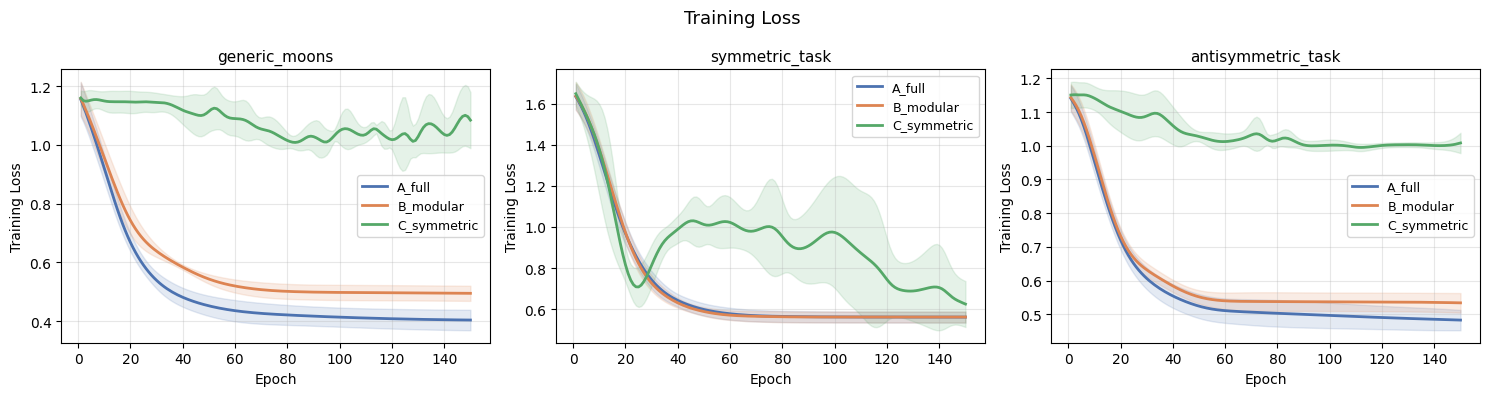

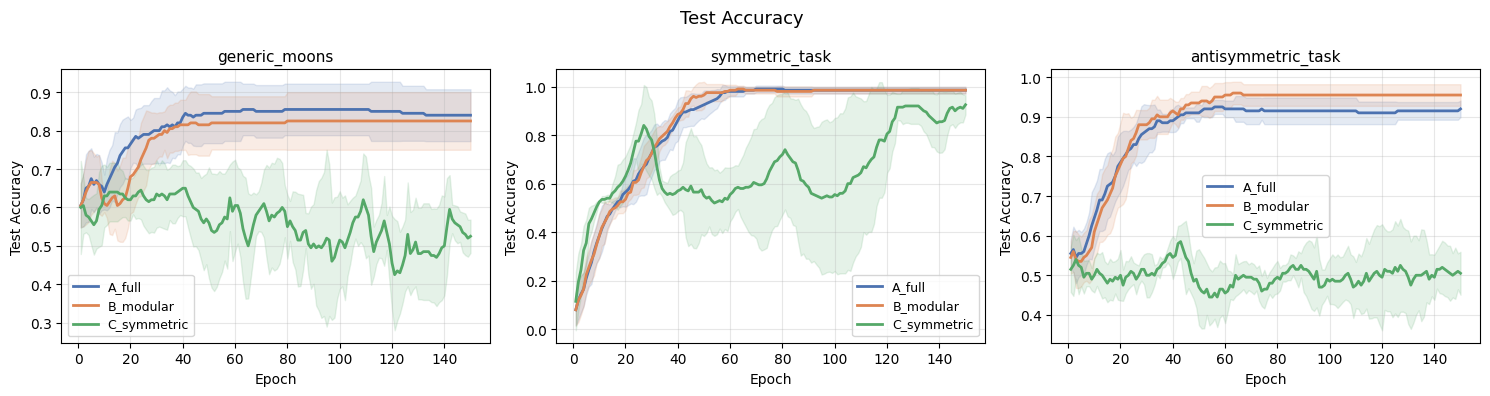

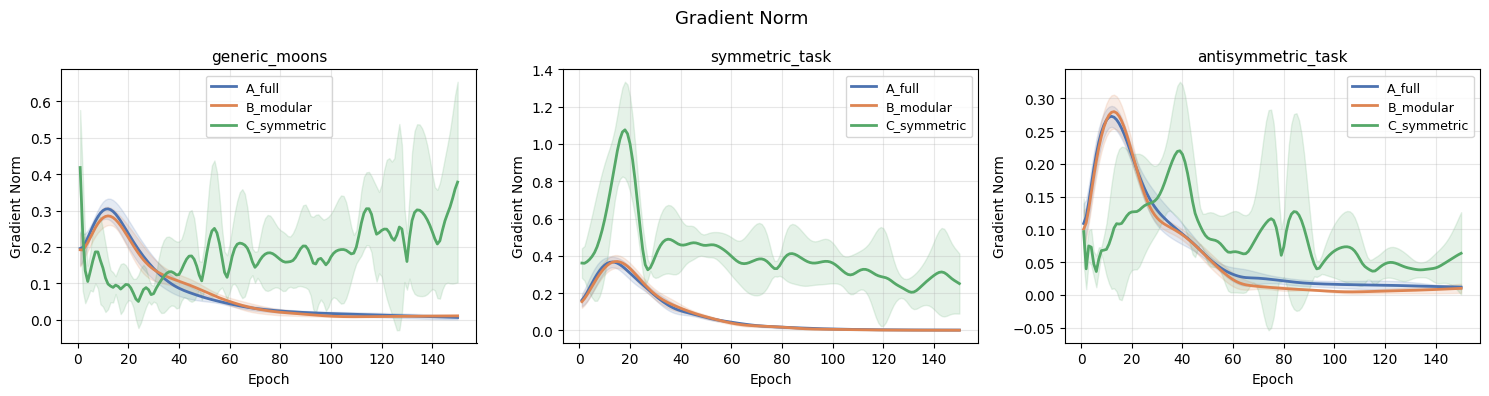

In [ ]:
MODEL_COLORS = {'A_full': '#4C72B0', 'B_modular': '#DD8452', 'C_symmetric': '#55A868'}

def plot_curves(hist_df, metric, ylabel, title_suffix=''):
    datasets = hist_df['dataset'].unique()
    fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4), sharey=False)
    if len(datasets) == 1:
        axes = [axes]

    for ax, ds in zip(axes, datasets):
        sub = hist_df[hist_df['dataset'] == ds]
        for model in sub['model'].unique():
            grp  = sub[sub['model'] == model].groupby('epoch')[metric]
            mean = grp.mean()
            std  = grp.std().fillna(0)
            ax.plot(mean.index, mean.values,
                    label=model, color=MODEL_COLORS.get(model, 'gray'), lw=2)
            ax.fill_between(mean.index, mean - std, mean + std,
                            alpha=0.15, color=MODEL_COLORS.get(model, 'gray'))
        ax.set_title(ds, fontsize=11)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle(f'{ylabel} {title_suffix}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{metric}_curves.pdf', bbox_inches='tight')
    plt.show()


plot_curves(hist_df, 'train_loss', 'Training Loss')
plot_curves(hist_df, 'test_acc',   'Test Accuracy')
plot_curves(hist_df, 'grad_norm',  'Gradient Norm')

---
## 7. 2D Loss Landscape Slice

Loss landscape: A_full...
Loss landscape: B_modular...
Loss landscape: C_symmetric...


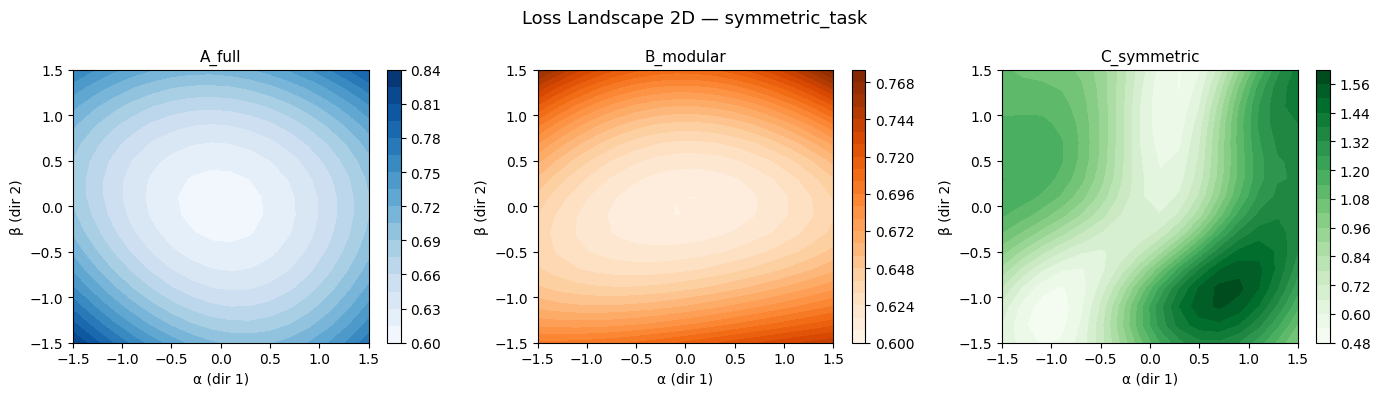

In [ ]:
def loss_landscape_2d(builder, dataset_fn, seed=0, n_points=18, radius=1.5):
    """
    Fija los parámetros en el óptimo encontrado y barre dos
    direcciones aleatorias del espacio de parámetros.
    Un paisaje muy plano sugiere barren plateau.
    """
    X_train, X_test, y_train, y_test = dataset_fn(seed=seed)
    result = train_model(X_train, y_train, X_test, y_test,
                         ansatz_builder=builder, n_epochs=N_EPOCHS,
                         lr=LR, seed=seed)

    theta_star = result['theta']
    qc, params = result['ansatz_circuit'], result['ansatz_params']
    n_params   = len(theta_star)

    rng = np.random.default_rng(seed)
    d1  = rng.normal(size=n_params); d1 /= np.linalg.norm(d1)
    d2  = rng.normal(size=n_params); d2 /= np.linalg.norm(d2)

    alphas = np.linspace(-radius, radius, n_points)
    betas  = np.linspace(-radius, radius, n_points)
    Z      = np.zeros((n_points, n_points))

    for i, a in enumerate(alphas):
        for j, b in enumerate(betas):
            th  = theta_star + a * d1 + b * d2
            Z[i, j] = mse_loss(X_train, y_train, th, qc, params)

    return alphas, betas, Z


# Draw loss landscapes for the 3 circuits on symmetric_task
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, builder), color in zip(axes, BUILDERS.items(), ['Blues', 'Oranges', 'Greens']):
    print(f'Loss landscape: {name}...')
    a, b, Z = loss_landscape_2d(builder, dataset_symmetric, n_points=16)
    cf = ax.contourf(a, b, Z, levels=20, cmap=color)
    plt.colorbar(cf, ax=ax)
    ax.set_title(f'{name}', fontsize=11)
    ax.set_xlabel('α (dir 1)')
    ax.set_ylabel('β (dir 2)')

plt.suptitle('Loss Landscape 2D — symmetric_task', fontsize=13)
plt.tight_layout()
plt.savefig('loss_landscape.pdf', bbox_inches='tight')
plt.show()

---
## 8. Results Table and Generalization Metrics

In [ ]:
def ms(series):
    """Formatea mean ± std."""
    return f'{series.mean():.4f} ± {series.std():.4f}'

summary = (
    runs_df.groupby(['dataset', 'model'])
    .agg(
        n_params         = ('n_params',           'mean'),
        mw_Q             = ('model',               lambda s: mw_results.get(s.iloc[0], (np.nan,))[0]),
        bp_var           = ('model',               lambda s: bp_results.get(s.iloc[0], np.nan)),
        init_grad        = ('initial_grad_norm',   ms),
        train_loss       = ('final_train_loss',    ms),
        test_loss        = ('final_test_loss',     ms),
        train_acc        = ('final_train_acc',     ms),
        test_acc         = ('final_test_acc',      ms),
        gen_gap_acc      = ('gen_gap_acc',         ms),
        convergence_epoch= ('convergence_epoch',   ms),
    )
    .reset_index()
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(summary.to_string(index=False))

           dataset       model  n_params     mw_Q   bp_var       init_grad      train_loss       test_loss       train_acc        test_acc     gen_gap_acc convergence_epoch
antisymmetric_task      A_full      28.0 0.742744 0.006085 0.1091 ± 0.0305 0.4831 ± 0.0303 0.5101 ± 0.0338 0.9567 ± 0.0070 0.9200 ± 0.0209 0.0367 ± 0.0247  21.6000 ± 2.4083
antisymmetric_task   B_modular      20.0 0.364328 0.009607 0.1004 ± 0.0290 0.5342 ± 0.0291 0.5490 ± 0.0313 0.9667 ± 0.0295 0.9550 ± 0.0274 0.0283 ± 0.0192  22.2000 ± 1.6432
antisymmetric_task C_symmetric      12.0 0.664437 0.061462 0.0966 ± 0.0504 1.0082 ± 0.0302 1.0158 ± 0.0323 0.5267 ± 0.0260 0.5050 ± 0.0542 0.0583 ± 0.0391 150.0000 ± 0.0000
     generic_moons      A_full      28.0 0.742744 0.006085 0.1959 ± 0.0464 0.4034 ± 0.0349 0.4581 ± 0.0812 0.8767 ± 0.0360 0.8400 ± 0.0675 0.0533 ± 0.0871  21.0000 ± 5.8737
     generic_moons   B_modular      20.0 0.364328 0.009607 0.1924 ± 0.0459 0.4944 ± 0.0258 0.5520 ± 0.0700 0.8700 ± 0.0209 0.8250 ± 0.0

---
## 9. LaTeX Table Ready for the Paper

In [ ]:
def best_model_per_metric(runs_df, dataset, metric, higher_is_better=True):
    grp = runs_df[runs_df['dataset'] == dataset].groupby('model')[metric].mean()
    return grp.idxmax() if higher_is_better else grp.idxmin()


def generate_latex_table(runs_df, mw_results, bp_results):
    datasets = runs_df['dataset'].unique()
    models   = runs_df['model'].unique()

    lines = []
    lines.append(r'\begin{table*}[ht]')
    lines.append(r'\centering')
    lines.append(r'\caption{Experimental results: mean $\pm$ std.\ dev.\ over ' +
                 str(len(SEEDS)) + r' seeds, ' + str(N_EPOCHS) + r' epochs.}')
    lines.append(r'\label{tab:results}')
    lines.append(r'\renewcommand{\arraystretch}{1.2}')
    lines.append(r'\begin{tabular}{llrrrrrr}')
    lines.append(r'\toprule')
    lines.append(r'Dataset & Model & $|\theta|$ & $Q_{MW}$ & $\mathrm{Var}[\nabla]$ '
                 r'& Test Acc & Gen.~Gap & Conv.~Epoch \\')
    lines.append(r'\midrule')

    for ds in datasets:
        sub = runs_df[runs_df['dataset'] == ds]
        best_acc  = best_model_per_metric(runs_df, ds, 'final_test_acc',  True)
        best_gap  = best_model_per_metric(runs_df, ds, 'gen_gap_acc',     False)
        best_conv = best_model_per_metric(runs_df, ds, 'convergence_epoch', False)

        first = True
        for model in models:
            msub = sub[sub['model'] == model]
            if msub.empty:
                continue

            n_p  = int(msub['n_params'].mean())
            q_mw = mw_results.get(model, (float('nan'),))[0]
            bp_v = bp_results.get(model, float('nan'))

            acc_str  = f'{msub["final_test_acc"].mean():.3f} $\\pm$ {msub["final_test_acc"].std():.3f}'
            gap_str  = f'{msub["gen_gap_acc"].mean():.3f} $\\pm$ {msub["gen_gap_acc"].std():.3f}'
            conv_str = f'{msub["convergence_epoch"].mean():.1f} $\\pm$ {msub["convergence_epoch"].std():.1f}'

            if model == best_acc:  acc_str  = r'\textbf{' + acc_str  + '}'
            if model == best_gap:  gap_str  = r'\textbf{' + gap_str  + '}'
            if model == best_conv: conv_str = r'\textbf{' + conv_str + '}'

            ds_cell = ds.replace('_', '\\_') if first else ''
            first   = False

            lines.append(
                f'{ds_cell} & {model.replace("_", "\_")} & {n_p} & '
                f'{q_mw:.3f} & {bp_v:.5f} & '
                f'{acc_str} & {gap_str} & {conv_str} \\\\'
            )
        lines.append(r'\midrule')

    lines[-1] = r'\bottomrule'
    lines.append(r'\end{tabular}')
    lines.append(r'\end{table*}')
    return '\n'.join(lines)


latex_table = generate_latex_table(runs_df, mw_results, bp_results)
print(latex_table)

with open('results_table.tex', 'w') as f:
    f.write(latex_table)
print('\nTable saved to results_table.tex')

\begin{table*}[ht]
\centering
\caption{Experimental results: mean $\pm$ std.\ dev.\ over 5 seeds, 150 epochs.}
\label{tab:results}
\renewcommand{\arraystretch}{1.2}
\begin{tabular}{llrrrrrr}
\toprule
Dataset & Model & $|\theta|$ & $Q_{MW}$ & $\mathrm{Var}[\nabla]$ & Test Acc & Gen.~Gap & Conv.~Epoch \\
\midrule
generic\_moons & A\_full & 28 & 0.743 & 0.00609 & \textbf{0.840 $\pm$ 0.068} & 0.053 $\pm$ 0.087 & \textbf{21.0 $\pm$ 5.9} \\
 & B\_modular & 20 & 0.364 & 0.00961 & 0.825 $\pm$ 0.075 & 0.055 $\pm$ 0.082 & 23.8 $\pm$ 3.5 \\
 & C\_symmetric & 12 & 0.664 & 0.06146 & 0.525 $\pm$ 0.043 & \textbf{0.013 $\pm$ 0.022} & 150.0 $\pm$ 0.0 \\
\midrule
symmetric\_task & A\_full & 28 & 0.743 & 0.00609 & \textbf{0.985 $\pm$ 0.014} & \textbf{0.042 $\pm$ 0.026} & 38.2 $\pm$ 8.8 \\
 & B\_modular & 20 & 0.364 & 0.00961 & 0.985 $\pm$ 0.014 & 0.042 $\pm$ 0.026 & 36.6 $\pm$ 6.3 \\
 & C\_symmetric & 12 & 0.664 & 0.06146 & 0.925 $\pm$ 0.040 & 0.047 $\pm$ 0.048 & \textbf{24.6 $\pm$ 4.2} \\
\midrule
antis

---
## 10. Automatic Results Summary

In [ ]:
def auto_conclusions(runs_df, mw_results, bp_results):
    lines = []
    lines.append('=== AUTOMATIC RESULTS SUMMARY ===')

    # Expressibility
    best_mw  = max(mw_results, key=lambda k: mw_results[k][0])
    worst_mw = min(mw_results, key=lambda k: mw_results[k][0])
    lines.append(f'\n[EXPRESSIBILITY]')
    lines.append(f'  Highest Meyer-Wallach Q: {best_mw} (Q={mw_results[best_mw][0]:.4f})')
    lines.append(f'  Lowest Meyer-Wallach Q: {worst_mw} (Q={mw_results[worst_mw][0]:.4f})')

    # Barren plateau
    best_bp  = max(bp_results, key=bp_results.get)   # higher variance → safer
    worst_bp = min(bp_results, key=bp_results.get)
    lines.append(f'\n[BARREN PLATEAU — higher Var is better]')
    lines.append(f'  Healthiest gradients: {best_bp}  (Var={bp_results[best_bp]:.6f})')
    lines.append(f'  Highest BP risk:      {worst_bp} (Var={bp_results[worst_bp]:.6f})')

    # Per dataset
    for ds in runs_df['dataset'].unique():
        sub = runs_df[runs_df['dataset'] == ds]
        agg = sub.groupby('model').agg({
            'final_test_acc'  : 'mean',
            'gen_gap_acc'     : 'mean',
            'convergence_epoch': 'mean',
        })
        best_acc  = agg['final_test_acc'].idxmax()
        best_gap  = agg['gen_gap_acc'].idxmin()
        best_conv = agg['convergence_epoch'].idxmin()
        lines.append(f'\n[DATASET: {ds}]')
        lines.append(f'  Best test accuracy   : {best_acc}  ({agg.loc[best_acc, "final_test_acc"]:.4f})')
        lines.append(f'  Lowest gen. gap (acc): {best_gap}  ({agg.loc[best_gap, "gen_gap_acc"]:.4f})')
        lines.append(f'  Fastest convergence  : {best_conv} (epoch {agg.loc[best_conv, "convergence_epoch"]:.1f})')

        # Automatic hypothesis conclusion
        if ds == 'symmetric_task' and best_acc == 'C_symmetric':
            lines.append('  -> HYPOTHESIS CONFIRMED: C_symmetric wins on the symmetric task.')
        elif ds == 'symmetric_task':
            lines.append(f'  -> HYPOTHESIS NOT CONFIRMED: {best_acc} wins on the symmetric task.')
        if ds == 'antisymmetric_task':
            lines.append(f'  -> Negative control: {best_acc} wins (expected: advantage of A or B).')

    return '\n'.join(lines)


conclusions = auto_conclusions(runs_df, mw_results, bp_results)
print(conclusions)

with open('conclusions.txt', 'w') as f:
    f.write(conclusions)

=== AUTOMATIC RESULTS SUMMARY ===

[EXPRESSIBILITY]
  Highest Meyer-Wallach Q: A_full (Q=0.7427)
  Lowest Meyer-Wallach Q: B_modular (Q=0.3643)

[BARREN PLATEAU — higher Var is better]
  Healthiest gradients: C_symmetric  (Var=0.061462)
  Highest BP risk:      A_full (Var=0.006085)

[DATASET: generic_moons]
  Best test accuracy   : A_full  (0.8400)
  Lowest gen. gap (acc): C_symmetric  (0.0133)
  Fastest convergence  : A_full (epoch 21.0)

[DATASET: symmetric_task]
  Best test accuracy   : A_full  (0.9850)
  Lowest gen. gap (acc): A_full  (0.0417)
  Fastest convergence  : C_symmetric (epoch 24.6)
  -> HYPOTHESIS NOT CONFIRMED: A_full wins on the symmetric task.

[DATASET: antisymmetric_task]
  Best test accuracy   : B_modular  (0.9550)
  Lowest gen. gap (acc): B_modular  (0.0283)
  Fastest convergence  : A_full (epoch 21.6)
  -> Negative control: B_modular wins (expected: advantage of A or B).


---
## 11. Final Summary Panel

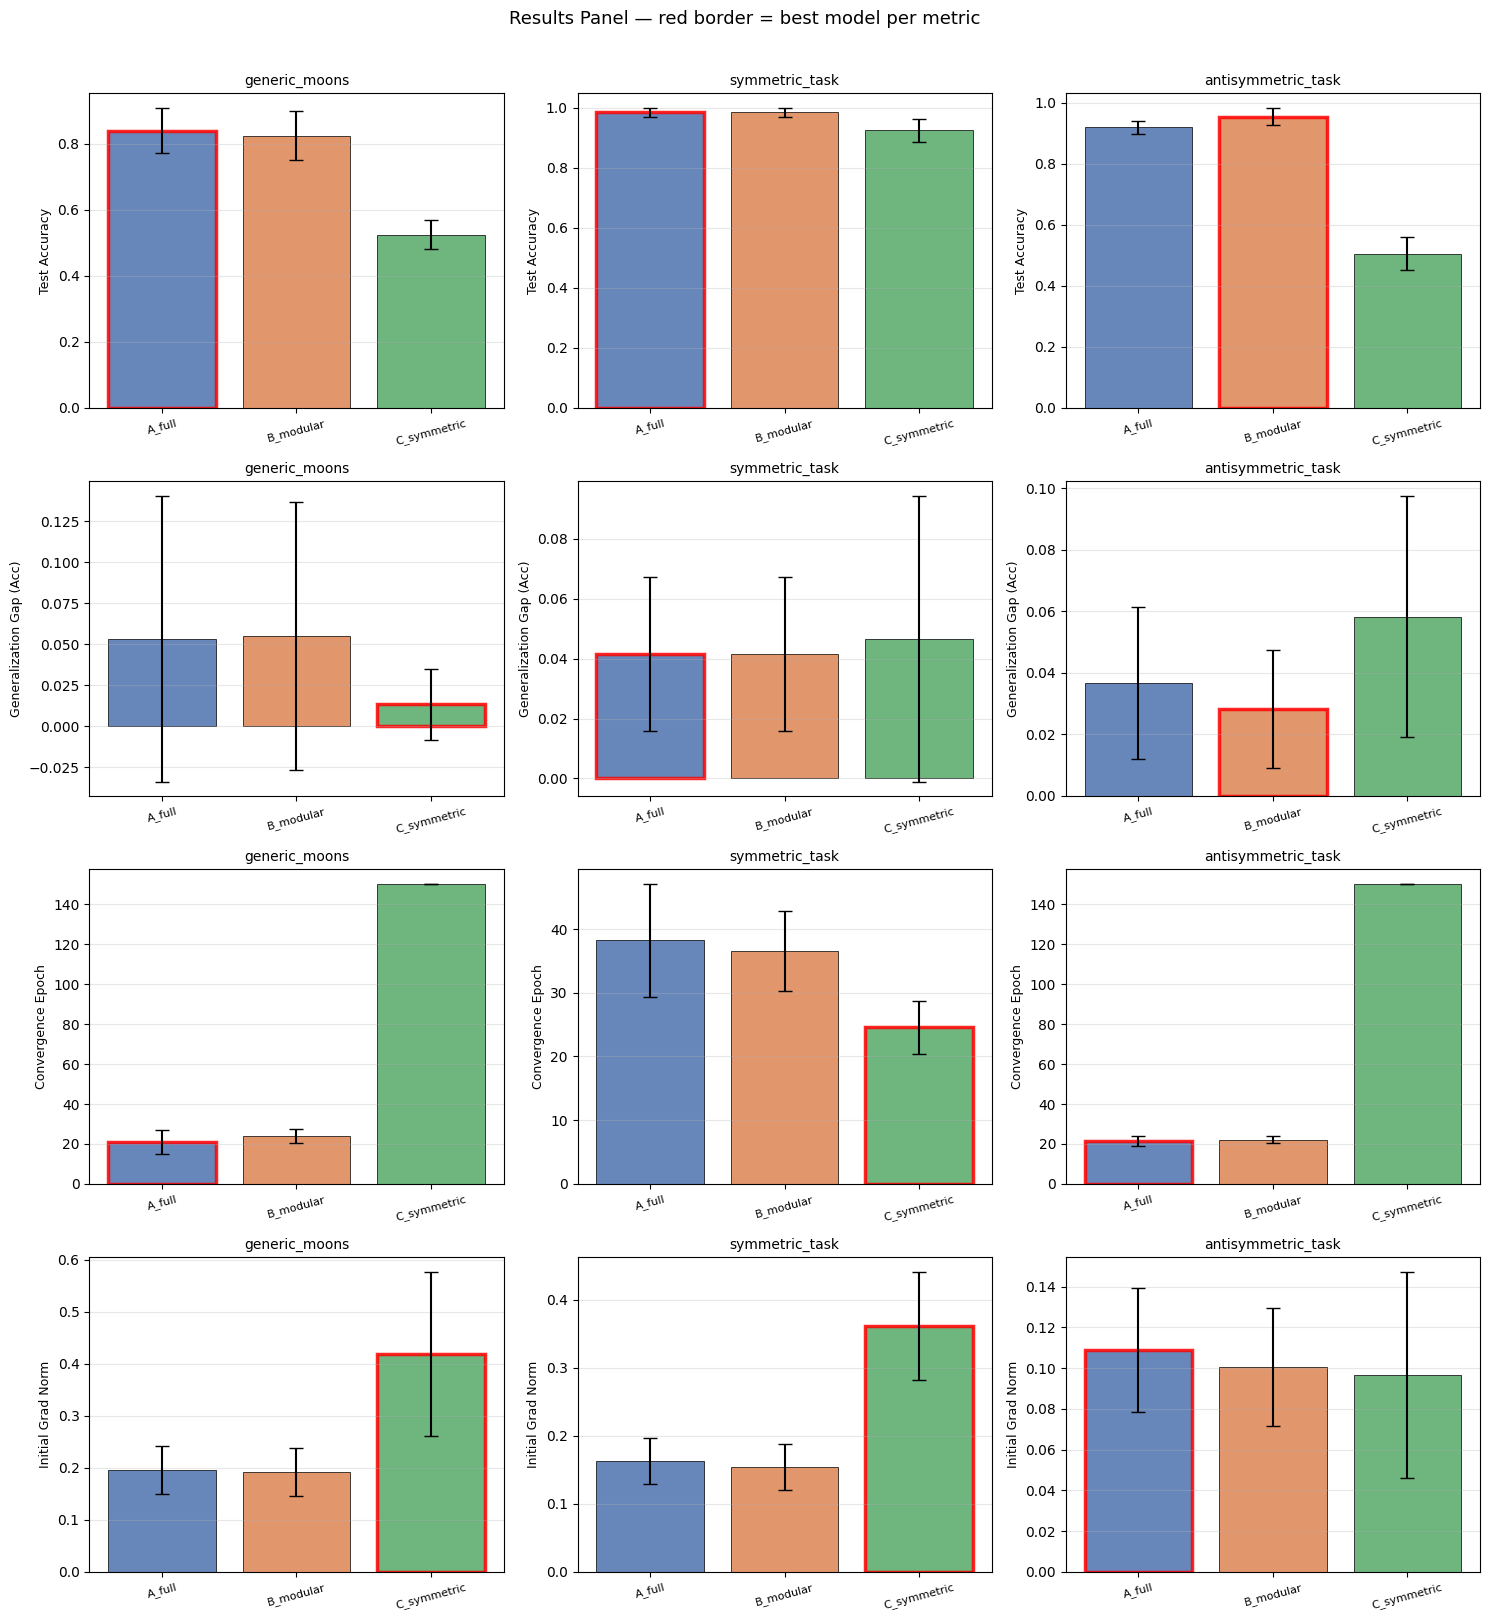

Figures saved as PDF.


In [ ]:
datasets = runs_df['dataset'].unique()
metrics  = [
    ('final_test_acc',   'Test Accuracy',    True),
    ('gen_gap_acc',      'Generalization Gap (Acc)', False),
    ('convergence_epoch','Convergence Epoch', False),
    ('initial_grad_norm','Initial Grad Norm', True),
]

fig, axes = plt.subplots(len(metrics), len(datasets),
                          figsize=(5 * len(datasets), 4 * len(metrics)))

for row_idx, (metric, ylabel, higher_better) in enumerate(metrics):
    for col_idx, ds in enumerate(datasets):
        ax  = axes[row_idx][col_idx]
        sub = runs_df[runs_df['dataset'] == ds]
        grp = sub.groupby('model')[metric]
        means = grp.mean()
        stds  = grp.std().fillna(0)

        bar_colors = [MODEL_COLORS.get(m, 'gray') for m in means.index]
        bars = ax.bar(means.index, means.values, yerr=stds.values,
                      capsize=5, color=bar_colors, alpha=0.85,
                      edgecolor='black', linewidth=0.6)

        # Mark the best
        best = means.idxmax() if higher_better else means.idxmin()
        best_idx = list(means.index).index(best)
        bars[best_idx].set_edgecolor('red')
        bars[best_idx].set_linewidth(2.5)

        ax.set_title(f'{ds}', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_xticklabels(means.index, rotation=15, fontsize=8)
        ax.grid(axis='y', alpha=0.3)

plt.suptitle('Results Panel — red border = best model per metric',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('summary_panel.pdf', bbox_inches='tight')
plt.show()
print('Figures saved as PDF.')

---
## Generated Files

| Archivo | Contenido |
|---|---|
| `expressibility.pdf` | Meyer-Wallach Q bars |
| `barren_plateau.pdf` | Gradient distribution per circuit |
| `train_loss_curves.pdf` | Loss curves |
| `test_acc_curves.pdf` | Accuracy curves |
| `grad_norm_curves.pdf` | Gradient norm evolution |
| `loss_landscape.pdf` | 2D Loss landscape |
| `summary_panel.pdf` | Comparative metrics panel |
| `results_table.tex` | LaTeX Table Ready for the Paper |
| `conclusions.txt` | Automatic Results Summary |